# FEM Surrogate — Entraînement du modèle

Ce notebook permet d'entraîner le modèle LightGBM complet depuis les splits déjà préparés.

**Étapes :**
1. Chargement des données
2. Préparation des features
3. Hyperparamètres (réglage manuel ou Optuna)
4. Entraînement
5. Évaluation
6. Sauvegarde du modèle

In [21]:
import sys
import pathlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import OrdinalEncoder

ROOT      = pathlib.Path('..')
PROC_DIR  = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'data' / 'models' / 'advanced'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

EPS         = 1e-12
TARGET_COLS = ['max_displacement_m', 'max_von_mises_pa']
DROP_COLS   = ['simulation_id', 'timestamp', 'solver_name', 'solver_version',
               'data_version', 'mesh_nx', 'mesh_ny']
CAT_COLS    = ['geometry_type', 'material_category', 'dimension_category']

print('OK')

OK


---
## 1. Chargement des données

In [22]:
train = pd.read_parquet(PROC_DIR / 'train.parquet')
val   = pd.read_parquet(PROC_DIR / 'val.parquet')
test  = pd.read_parquet(PROC_DIR / 'test.parquet')

print(f'Train : {len(train):,} lignes')
print(f'Val   : {len(val):,} lignes')
print(f'Test  : {len(test):,} lignes')
print(f'Colonnes : {list(train.columns)}')

Train : 42,855 lignes
Val   : 9,341 lignes
Test  : 9,354 lignes
Colonnes : ['simulation_id', 'timestamp', 'max_displacement_m', 'max_von_mises_pa', 'solver_name', 'solver_version', 'data_version', 'material_category', 'dimension_category', 'length_m', 'height_m', 'young_modulus_pa', 'poisson_ratio', 'traction_pa', 'mesh_nx', 'mesh_ny', 'hole_radius_ratio', 'geometry_type', 'hole_cx_ratio', 'hole_cy_ratio', 'has_hole', 'has_moving_hole', 'area_m2', 'aspect_ratio', 'radius_abs', 'd_over_W', 'Kt_theory', 'net_section_ratio', 'sigma_net', 'epsilon', 'delta_theory', 'biaxial_factor', 'lig_left', 'lig_right', 'lig_bottom', 'lig_top', 'lig_min', 'edge_ratio', 'eccentricity_x', 'eccentricity_y', 'eccentricity', 'stress_amp_proxy', 'logE', 'logS', 'log_epsilon', 'log_delta_th', 'log_sigma_net', 'log_Kt', 'log_lig_min', 'log_edge_ratio', 'traction_over_E']


---
## 2. Préparation des features

In [ ]:
f
e
a
t
_
c
o
l
s
 
=
 
[
c
 
f
o
r
 
c
 
i
n
 
t
r
a
i
n
.
c
o
l
u
m
n
s
 
i
f
 
c
 
n
o
t
 
i
n
 
T
A
R
G
E
T
_
C
O
L
S
 
+
 
D
R
O
P
_
C
O
L
S
]

p
r
i
n
t
(
f
'
F
e
a
t
u
r
e
s
 
:
 
{
l
e
n
(
f
e
a
t
_
c
o
l
s
)
}
'
)

p
r
i
n
t
(
f
e
a
t
_
c
o
l
s
)


#
 
O
r
d
i
n
a
l
 
e
n
c
o
d
i
n
g
 
o
f
 
c
a
t
e
g
o
r
i
c
a
l
 
c
o
l
u
m
n
s

e
n
c
 
=
 
O
r
d
i
n
a
l
E
n
c
o
d
e
r
(
h
a
n
d
l
e
_
u
n
k
n
o
w
n
=
'
u
s
e
_
e
n
c
o
d
e
d
_
v
a
l
u
e
'
,
 
u
n
k
n
o
w
n
_
v
a
l
u
e
=
-
1
)

f
o
r
 
d
f
_
 
i
n
 
[
t
r
a
i
n
,
 
v
a
l
,
 
t
e
s
t
]
:

 
 
 
 
d
f
_
[
C
A
T
_
C
O
L
S
]
 
=
 
e
n
c
.
f
i
t
_
t
r
a
n
s
f
o
r
m
(
d
f
_
[
C
A
T
_
C
O
L
S
]
.
a
s
t
y
p
e
(
s
t
r
)
)


X
_
t
r
a
i
n
 
=
 
t
r
a
i
n
[
f
e
a
t
_
c
o
l
s
]
.
a
s
t
y
p
e
(
f
l
o
a
t
)

X
_
v
a
l
 
 
 
=
 
v
a
l
[
f
e
a
t
_
c
o
l
s
]
.
a
s
t
y
p
e
(
f
l
o
a
t
)

X
_
t
e
s
t
 
 
=
 
t
e
s
t
[
f
e
a
t
_
c
o
l
s
]
.
a
s
t
y
p
e
(
f
l
o
a
t
)


p
r
i
n
t
(
f
'
\
n
N
u
l
l
s
 
t
r
a
i
n
 
:
 
{
X
_
t
r
a
i
n
.
i
s
n
u
l
l
(
)
.
s
u
m
(
)
.
s
u
m
(
)
}
'
)

p
r
i
n
t
(
f
'
N
u
l
l
s
 
v
a
l
 
 
 
:
 
{
X
_
v
a
l
.
i
s
n
u
l
l
(
)
.
s
u
m
(
)
.
s
u
m
(
)
}
'
)

p
r
i
n
t
(
f
'
N
u
l
l
s
 
t
e
s
t
 
 
:
 
{
X
_
t
e
s
t
.
i
s
n
u
l
l
(
)
.
s
u
m
(
)
.
s
u
m
(
)
}
'
)

---
## 3. Configuration de l'entraînement

**Deux modes :**
- `USE_OPTUNA = False` → entraîne directement avec les hyperparamètres définis dans `MANUAL_PARAMS` (rapide, ~1 min)
- `USE_OPTUNA = True` → recherche automatique des meilleurs hyperparamètres (lent, 20-60 min selon `N_TRIALS`)

In [ ]:
#
 
─
─
 
M
o
d
e
 
s
e
l
e
c
t
i
o
n
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

U
S
E
_
O
P
T
U
N
A
 
=
 
F
a
l
s
e
 
 
 
#
 
T
r
u
e
 
=
 
O
p
t
u
n
a
 
s
e
a
r
c
h
 
|
 
F
a
l
s
e
 
=
 
m
a
n
u
a
l
 
p
a
r
a
m
e
t
e
r
s

N
_
T
R
I
A
L
S
 
 
 
=
 
4
0
 
 
 
 
 
#
 
N
u
m
b
e
r
 
o
f
 
O
p
t
u
n
a
 
t
r
i
a
l
s
 
(
i
g
n
o
r
e
d
 
i
f
 
U
S
E
_
O
P
T
U
N
A
=
F
a
l
s
e
)

C
V
_
F
O
L
D
S
 
 
 
=
 
5
 
 
 
 
 
 
#
 
F
o
l
d
s
 
f
o
r
 
O
p
t
u
n
a
 
c
r
o
s
s
-
v
a
l
i
d
a
t
i
o
n


#
 
─
─
 
M
a
n
u
a
l
 
h
y
p
e
r
p
a
r
a
m
e
t
e
r
s
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

#
 
A
d
j
u
s
t
 
t
h
e
s
e
 
v
a
l
u
e
s
 
t
o
 
f
i
n
e
-
t
u
n
e
 
t
h
e
 
m
o
d
e
l
 
w
i
t
h
o
u
t
 
r
u
n
n
i
n
g
 
O
p
t
u
n
a
.

M
A
N
U
A
L
_
P
A
R
A
M
S
 
=
 
{

 
 
 
 
'
n
_
e
s
t
i
m
a
t
o
r
s
'
:
 
 
 
 
 
 
1
0
0
0
,

 
 
 
 
'
l
e
a
r
n
i
n
g
_
r
a
t
e
'
:
 
 
 
 
 
0
.
0
5
,

 
 
 
 
'
n
u
m
_
l
e
a
v
e
s
'
:
 
 
 
 
 
 
 
 
1
2
7
,

 
 
 
 
'
m
a
x
_
d
e
p
t
h
'
:
 
 
 
 
 
 
 
 
 
8
,

 
 
 
 
'
m
i
n
_
c
h
i
l
d
_
s
a
m
p
l
e
s
'
:
 
2
0
,

 
 
 
 
'
s
u
b
s
a
m
p
l
e
'
:
 
 
 
 
 
 
 
 
 
0
.
8
,

 
 
 
 
'
c
o
l
s
a
m
p
l
e
_
b
y
t
r
e
e
'
:
 
 
0
.
8
,

 
 
 
 
'
r
e
g
_
a
l
p
h
a
'
:
 
 
 
 
 
 
 
 
 
0
.
1
,

 
 
 
 
'
r
e
g
_
l
a
m
b
d
a
'
:
 
 
 
 
 
 
 
 
1
.
0
,

}


#
 
─
─
 
M
o
n
o
t
o
n
i
c
i
t
y
 
c
o
n
s
t
r
a
i
n
t
s
 
(
p
h
y
s
i
c
s
)
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

M
O
N
O
_
C
O
N
S
T
R
A
I
N
T
S
_
M
A
P
 
=
 
{

 
 
 
 
'
t
r
a
c
t
i
o
n
_
p
a
'
:
 
 
 
 
 
 
 
+
1
,

 
 
 
 
'
y
o
u
n
g
_
m
o
d
u
l
u
s
_
p
a
'
:
 
 
-
1
,

 
 
 
 
'
l
o
g
S
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
+
1
,

 
 
 
 
'
l
o
g
E
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
-
1
,

 
 
 
 
'
l
o
g
_
s
i
g
m
a
_
n
e
t
'
:
 
 
 
 
 
+
1
,

 
 
 
 
'
s
i
g
m
a
_
n
e
t
'
:
 
 
 
 
 
 
 
 
 
+
1
,

 
 
 
 
'
l
o
g
_
d
e
l
t
a
_
t
h
'
:
 
 
 
 
 
 
+
1
,

 
 
 
 
'
d
e
l
t
a
_
t
h
e
o
r
y
'
:
 
 
 
 
 
 
+
1
,

 
 
 
 
'
e
p
s
i
l
o
n
'
:
 
 
 
 
 
 
 
 
 
 
 
+
1
,

 
 
 
 
'
h
o
l
e
_
r
a
d
i
u
s
_
r
a
t
i
o
'
:
 
+
1
,

 
 
 
 
'
d
_
o
v
e
r
_
W
'
:
 
 
 
 
 
 
 
 
 
 
+
1
,

 
 
 
 
'
K
t
_
t
h
e
o
r
y
'
:
 
 
 
 
 
 
 
 
 
+
1
,

 
 
 
 
'
e
d
g
e
_
r
a
t
i
o
'
:
 
 
 
 
 
 
 
 
+
1
,

 
 
 
 
'
n
e
t
_
s
e
c
t
i
o
n
_
r
a
t
i
o
'
:
 
-
1
,

 
 
 
 
'
l
i
g
_
m
i
n
'
:
 
 
 
 
 
 
 
 
 
 
 
-
1
,

}

m
o
n
o
_
c
o
n
s
t
r
a
i
n
t
s
 
=
 
[
M
O
N
O
_
C
O
N
S
T
R
A
I
N
T
S
_
M
A
P
.
g
e
t
(
c
,
 
0
)
 
f
o
r
 
c
 
i
n
 
f
e
a
t
_
c
o
l
s
]


p
r
i
n
t
(
f
'
M
o
d
e
 
:
 
{
"
O
p
t
u
n
a
 
(
"
 
+
 
s
t
r
(
N
_
T
R
I
A
L
S
)
 
+
 
"
 
t
r
i
a
l
s
)
"
 
i
f
 
U
S
E
_
O
P
T
U
N
A
 
e
l
s
e
 
"
P
a
r
a
m
è
t
r
e
s
 
m
a
n
u
e
l
s
"
}
'
)

p
r
i
n
t
(
f
'
T
a
r
g
e
t
s
 
à
 
e
n
t
r
a
î
n
e
r
 
:
 
{
T
A
R
G
E
T
_
C
O
L
S
}
'
)

---
## 4. Entraînement

In [ ]:
d
e
f
 
o
p
t
u
n
a
_
o
b
j
e
c
t
i
v
e
(
t
r
i
a
l
,
 
X
_
t
r
,
 
y
_
t
r
,
 
c
v
,
 
m
o
n
o
)
:

 
 
 
 
p
a
r
a
m
s
 
=
 
{

 
 
 
 
 
 
 
 
'
o
b
j
e
c
t
i
v
e
'
:
 
 
 
 
 
 
 
 
 
 
 
 
'
r
e
g
r
e
s
s
i
o
n
'
,

 
 
 
 
 
 
 
 
'
m
e
t
r
i
c
'
:
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
'
r
m
s
e
'
,

 
 
 
 
 
 
 
 
'
v
e
r
b
o
s
i
t
y
'
:
 
 
 
 
 
 
 
 
 
 
 
 
-
1
,

 
 
 
 
 
 
 
 
'
n
_
e
s
t
i
m
a
t
o
r
s
'
:
 
 
 
 
 
 
 
 
 
t
r
i
a
l
.
s
u
g
g
e
s
t
_
i
n
t
(
'
n
_
e
s
t
i
m
a
t
o
r
s
'
,
 
4
0
0
,
 
2
0
0
0
,
 
s
t
e
p
=
1
0
0
)
,

 
 
 
 
 
 
 
 
'
l
e
a
r
n
i
n
g
_
r
a
t
e
'
:
 
 
 
 
 
 
 
 
t
r
i
a
l
.
s
u
g
g
e
s
t
_
f
l
o
a
t
(
'
l
e
a
r
n
i
n
g
_
r
a
t
e
'
,
 
0
.
0
1
,
 
0
.
2
,
 
l
o
g
=
T
r
u
e
)
,

 
 
 
 
 
 
 
 
'
n
u
m
_
l
e
a
v
e
s
'
:
 
 
 
 
 
 
 
 
 
 
 
t
r
i
a
l
.
s
u
g
g
e
s
t
_
i
n
t
(
'
n
u
m
_
l
e
a
v
e
s
'
,
 
3
1
,
 
2
5
5
)
,

 
 
 
 
 
 
 
 
'
m
a
x
_
d
e
p
t
h
'
:
 
 
 
 
 
 
 
 
 
 
 
 
t
r
i
a
l
.
s
u
g
g
e
s
t
_
i
n
t
(
'
m
a
x
_
d
e
p
t
h
'
,
 
4
,
 
1
2
)
,

 
 
 
 
 
 
 
 
'
m
i
n
_
c
h
i
l
d
_
s
a
m
p
l
e
s
'
:
 
 
 
 
t
r
i
a
l
.
s
u
g
g
e
s
t
_
i
n
t
(
'
m
i
n
_
c
h
i
l
d
_
s
a
m
p
l
e
s
'
,
 
1
0
,
 
1
0
0
)
,

 
 
 
 
 
 
 
 
'
s
u
b
s
a
m
p
l
e
'
:
 
 
 
 
 
 
 
 
 
 
 
 
t
r
i
a
l
.
s
u
g
g
e
s
t
_
f
l
o
a
t
(
'
s
u
b
s
a
m
p
l
e
'
,
 
0
.
6
,
 
1
.
0
)
,

 
 
 
 
 
 
 
 
'
c
o
l
s
a
m
p
l
e
_
b
y
t
r
e
e
'
:
 
 
 
 
 
t
r
i
a
l
.
s
u
g
g
e
s
t
_
f
l
o
a
t
(
'
c
o
l
s
a
m
p
l
e
_
b
y
t
r
e
e
'
,
 
0
.
5
,
 
1
.
0
)
,

 
 
 
 
 
 
 
 
'
r
e
g
_
a
l
p
h
a
'
:
 
 
 
 
 
 
 
 
 
 
 
 
t
r
i
a
l
.
s
u
g
g
e
s
t
_
f
l
o
a
t
(
'
r
e
g
_
a
l
p
h
a
'
,
 
1
e
-
8
,
 
1
0
.
0
,
 
l
o
g
=
T
r
u
e
)
,

 
 
 
 
 
 
 
 
'
r
e
g
_
l
a
m
b
d
a
'
:
 
 
 
 
 
 
 
 
 
 
 
t
r
i
a
l
.
s
u
g
g
e
s
t
_
f
l
o
a
t
(
'
r
e
g
_
l
a
m
b
d
a
'
,
 
1
e
-
8
,
 
1
0
.
0
,
 
l
o
g
=
T
r
u
e
)
,

 
 
 
 
 
 
 
 
'
m
o
n
o
t
o
n
e
_
c
o
n
s
t
r
a
i
n
t
s
'
:
 
m
o
n
o
,

 
 
 
 
 
 
 
 
'
n
_
j
o
b
s
'
:
 
-
1
,
 
'
r
a
n
d
o
m
_
s
t
a
t
e
'
:
 
4
2
,

 
 
 
 
}

 
 
 
 
r
m
s
e
s
 
=
 
[
]

 
 
 
 
f
o
r
 
t
r
_
i
d
x
,
 
v
l
_
i
d
x
 
i
n
 
c
v
.
s
p
l
i
t
(
X
_
t
r
)
:

 
 
 
 
 
 
 
 
m
 
=
 
l
g
b
.
L
G
B
M
R
e
g
r
e
s
s
o
r
(
*
*
p
a
r
a
m
s
)

 
 
 
 
 
 
 
 
m
.
f
i
t
(
X
_
t
r
.
i
l
o
c
[
t
r
_
i
d
x
]
,
 
y
_
t
r
[
t
r
_
i
d
x
]
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
e
v
a
l
_
s
e
t
=
[
(
X
_
t
r
.
i
l
o
c
[
v
l
_
i
d
x
]
,
 
y
_
t
r
[
v
l
_
i
d
x
]
)
]
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
c
a
l
l
b
a
c
k
s
=
[
l
g
b
.
e
a
r
l
y
_
s
t
o
p
p
i
n
g
(
5
0
,
 
v
e
r
b
o
s
e
=
F
a
l
s
e
)
,
 
l
g
b
.
l
o
g
_
e
v
a
l
u
a
t
i
o
n
(
-
1
)
]
)

 
 
 
 
 
 
 
 
r
m
s
e
s
.
a
p
p
e
n
d
(
n
p
.
s
q
r
t
(
m
e
a
n
_
s
q
u
a
r
e
d
_
e
r
r
o
r
(
y
_
t
r
[
v
l
_
i
d
x
]
,
 
m
.
p
r
e
d
i
c
t
(
X
_
t
r
.
i
l
o
c
[
v
l
_
i
d
x
]
)
)
)
)

 
 
 
 
r
e
t
u
r
n
 
f
l
o
a
t
(
n
p
.
m
e
a
n
(
r
m
s
e
s
)
)



t
r
a
i
n
e
d
_
m
o
d
e
l
s
 
=
 
{
}

b
e
s
t
_
p
a
r
a
m
s
_
p
e
r
_
t
a
r
g
e
t
 
=
 
{
}


f
o
r
 
t
a
r
g
e
t
 
i
n
 
T
A
R
G
E
T
_
C
O
L
S
:

 
 
 
 
p
r
i
n
t
(
f
'
\
n
{
"
=
"
*
5
5
}
'
)

 
 
 
 
p
r
i
n
t
(
f
'
 
 
T
a
r
g
e
t
 
:
 
{
t
a
r
g
e
t
}
'
)

 
 
 
 
p
r
i
n
t
(
f
'
{
"
=
"
*
5
5
}
'
)


 
 
 
 
y
_
t
r
a
i
n
_
l
o
g
 
=
 
n
p
.
l
o
g
1
0
(
t
r
a
i
n
[
t
a
r
g
e
t
]
.
c
l
i
p
(
E
P
S
)
.
v
a
l
u
e
s
)

 
 
 
 
y
_
v
a
l
_
l
o
g
 
 
 
=
 
n
p
.
l
o
g
1
0
(
v
a
l
[
t
a
r
g
e
t
]
.
c
l
i
p
(
E
P
S
)
.
v
a
l
u
e
s
)


 
 
 
 
i
f
 
U
S
E
_
O
P
T
U
N
A
:

 
 
 
 
 
 
 
 
p
r
i
n
t
(
f
'
 
 
O
p
t
u
n
a
 
:
 
{
N
_
T
R
I
A
L
S
}
 
t
r
i
a
l
s
,
 
{
C
V
_
F
O
L
D
S
}
-
f
o
l
d
 
C
V
 
.
.
.
'
)

 
 
 
 
 
 
 
 
c
v
 
=
 
K
F
o
l
d
(
n
_
s
p
l
i
t
s
=
C
V
_
F
O
L
D
S
,
 
s
h
u
f
f
l
e
=
T
r
u
e
,
 
r
a
n
d
o
m
_
s
t
a
t
e
=
4
2
)

 
 
 
 
 
 
 
 
s
t
u
d
y
 
=
 
o
p
t
u
n
a
.
c
r
e
a
t
e
_
s
t
u
d
y
(
d
i
r
e
c
t
i
o
n
=
'
m
i
n
i
m
i
z
e
'
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
s
a
m
p
l
e
r
=
o
p
t
u
n
a
.
s
a
m
p
l
e
r
s
.
T
P
E
S
a
m
p
l
e
r
(
s
e
e
d
=
4
2
)
)

 
 
 
 
 
 
 
 
s
t
u
d
y
.
o
p
t
i
m
i
z
e
(
l
a
m
b
d
a
 
t
:
 
o
p
t
u
n
a
_
o
b
j
e
c
t
i
v
e
(
t
,
 
X
_
t
r
a
i
n
,
 
y
_
t
r
a
i
n
_
l
o
g
,
 
c
v
,
 
m
o
n
o
_
c
o
n
s
t
r
a
i
n
t
s
)
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
n
_
t
r
i
a
l
s
=
N
_
T
R
I
A
L
S
,
 
s
h
o
w
_
p
r
o
g
r
e
s
s
_
b
a
r
=
T
r
u
e
)

 
 
 
 
 
 
 
 
b
e
s
t
_
p
a
r
a
m
s
 
=
 
s
t
u
d
y
.
b
e
s
t
_
p
a
r
a
m
s

 
 
 
 
 
 
 
 
p
r
i
n
t
(
f
'
 
 
M
e
i
l
l
e
u
r
 
R
M
S
E
(
l
o
g
)
 
C
V
 
:
 
{
s
t
u
d
y
.
b
e
s
t
_
v
a
l
u
e
:
.
5
f
}
'
)

 
 
 
 
 
 
 
 
p
r
i
n
t
(
f
'
 
 
M
e
i
l
l
e
u
r
s
 
p
a
r
a
m
s
 
:
 
{
b
e
s
t
_
p
a
r
a
m
s
}
'
)

 
 
 
 
e
l
s
e
:

 
 
 
 
 
 
 
 
b
e
s
t
_
p
a
r
a
m
s
 
=
 
M
A
N
U
A
L
_
P
A
R
A
M
S
.
c
o
p
y
(
)

 
 
 
 
 
 
 
 
p
r
i
n
t
(
f
'
 
 
P
a
r
a
m
è
t
r
e
s
 
m
a
n
u
e
l
s
 
u
t
i
l
i
s
é
s
.
'
)


 
 
 
 
b
e
s
t
_
p
a
r
a
m
s
_
p
e
r
_
t
a
r
g
e
t
[
t
a
r
g
e
t
]
 
=
 
b
e
s
t
_
p
a
r
a
m
s


 
 
 
 
#
 
F
i
n
a
l
 
t
r
a
i
n
i
n
g

 
 
 
 
f
i
n
a
l
_
p
a
r
a
m
s
 
=
 
{

 
 
 
 
 
 
 
 
'
o
b
j
e
c
t
i
v
e
'
:
 
'
r
e
g
r
e
s
s
i
o
n
'
,
 
'
m
e
t
r
i
c
'
:
 
'
r
m
s
e
'
,
 
'
v
e
r
b
o
s
i
t
y
'
:
 
-
1
,

 
 
 
 
 
 
 
 
'
m
o
n
o
t
o
n
e
_
c
o
n
s
t
r
a
i
n
t
s
'
:
 
m
o
n
o
_
c
o
n
s
t
r
a
i
n
t
s
,

 
 
 
 
 
 
 
 
'
n
_
j
o
b
s
'
:
 
-
1
,
 
'
r
a
n
d
o
m
_
s
t
a
t
e
'
:
 
4
2
,

 
 
 
 
 
 
 
 
*
*
b
e
s
t
_
p
a
r
a
m
s
,

 
 
 
 
}

 
 
 
 
m
o
d
e
l
 
=
 
l
g
b
.
L
G
B
M
R
e
g
r
e
s
s
o
r
(
*
*
f
i
n
a
l
_
p
a
r
a
m
s
)

 
 
 
 
m
o
d
e
l
.
f
i
t
(

 
 
 
 
 
 
 
 
X
_
t
r
a
i
n
,
 
y
_
t
r
a
i
n
_
l
o
g
,

 
 
 
 
 
 
 
 
e
v
a
l
_
s
e
t
=
[
(
X
_
v
a
l
,
 
y
_
v
a
l
_
l
o
g
)
]
,

 
 
 
 
 
 
 
 
c
a
l
l
b
a
c
k
s
=
[
l
g
b
.
e
a
r
l
y
_
s
t
o
p
p
i
n
g
(
5
0
,
 
v
e
r
b
o
s
e
=
F
a
l
s
e
)
,
 
l
g
b
.
l
o
g
_
e
v
a
l
u
a
t
i
o
n
(
1
0
0
)
]
,

 
 
 
 
)

 
 
 
 
t
r
a
i
n
e
d
_
m
o
d
e
l
s
[
t
a
r
g
e
t
]
 
=
 
m
o
d
e
l

 
 
 
 
p
r
i
n
t
(
f
'
 
 
E
n
t
r
a
î
n
e
m
e
n
t
 
t
e
r
m
i
n
é
.
 
b
e
s
t
_
i
t
e
r
a
t
i
o
n
=
{
m
o
d
e
l
.
b
e
s
t
_
i
t
e
r
a
t
i
o
n
_
}
'
)


p
r
i
n
t
(
'
\
n
T
o
u
s
 
l
e
s
 
m
o
d
è
l
e
s
 
e
n
t
r
a
î
n
é
s
.
'
)

---
## 5. Évaluation

In [26]:
def evaluate(model, X, y_orig):
    y_log   = np.log10(y_orig.clip(EPS))
    p_log   = model.predict(X)
    p_orig  = 10 ** p_log
    return {
        'R2_log':    r2_score(y_log, p_log),
        'RMSE_log':  np.sqrt(mean_squared_error(y_log, p_log)),
        'R2_orig':   r2_score(y_orig, p_orig),
        'RMSE_orig': np.sqrt(mean_squared_error(y_orig, p_orig)),
        'MAE_orig':  mean_absolute_error(y_orig, p_orig),
        'MAPE':      np.mean(np.abs((y_orig - p_orig) / (np.abs(y_orig) + EPS))),
        'p_log': p_log, 'y_log': y_log, 'p_orig': p_orig, 'y_orig': y_orig,
    }

results = {}
for target in TARGET_COLS:
    results[target] = {
        'val':  evaluate(trained_models[target], X_val,  val[target].values),
        'test': evaluate(trained_models[target], X_test, test[target].values),
    }

print(f'{"Target":28s} {"Split":5s}  {"R2_log":7s}  {"RMSE_log":9s}  {"R2_orig":7s}  {"MAPE":6s}')
print('-' * 70)
for target in TARGET_COLS:
    for split in ['val', 'test']:
        m = results[target][split]
        print(f'{target:28s} {split:5s}  {m["R2_log"]:7.4f}  '
              f'{m["RMSE_log"]:9.5f}  {m["R2_orig"]:7.4f}  {m["MAPE"]:6.4f}')

Target                       Split  R2_log   RMSE_log   R2_orig  MAPE  
----------------------------------------------------------------------
max_displacement_m           val     0.9910    0.05065   0.9436  0.0518
max_displacement_m           test    0.9913    0.04902   0.9749  0.0505
max_von_mises_pa             val     0.9935    0.03037   0.7222  0.0333
max_von_mises_pa             test    0.9946    0.02767   0.9508  0.0325


In [ ]:
#
 
─
─
 
P
r
e
d
i
c
t
e
d
 
v
s
 
a
c
t
u
a
l
 
p
l
o
t
s
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

c
o
l
o
r
s
 
=
 
{
'
w
i
t
h
_
h
o
l
e
'
:
 
'
#
2
1
9
6
F
3
'
,
 
'
w
i
t
h
_
h
o
l
e
_
m
o
v
i
n
g
'
:
 
'
#
F
F
5
7
2
2
'
,
 
'
w
i
t
h
o
u
t
_
h
o
l
e
'
:
 
'
#
4
C
A
F
5
0
'
}


f
i
g
,
 
a
x
e
s
 
=
 
p
l
t
.
s
u
b
p
l
o
t
s
(
1
,
 
2
,
 
f
i
g
s
i
z
e
=
(
1
3
,
 
5
)
)

f
i
g
.
s
u
p
t
i
t
l
e
(
'
P
r
é
d
i
t
 
v
s
 
R
é
e
l
 
—
 
T
e
s
t
 
s
e
t
 
(
é
c
h
e
l
l
e
 
l
o
g
1
0
)
'
,
 
f
o
n
t
s
i
z
e
=
1
3
,
 
f
o
n
t
w
e
i
g
h
t
=
'
b
o
l
d
'
)


f
o
r
 
a
x
,
 
t
a
r
g
e
t
 
i
n
 
z
i
p
(
a
x
e
s
,
 
T
A
R
G
E
T
_
C
O
L
S
)
:

 
 
 
 
m
 
 
 
 
=
 
r
e
s
u
l
t
s
[
t
a
r
g
e
t
]
[
'
t
e
s
t
'
]

 
 
 
 
g
e
o
m
 
=
 
t
e
s
t
[
'
g
e
o
m
e
t
r
y
_
t
y
p
e
'
]

 
 
 
 
f
o
r
 
g
e
o
m
_
v
a
l
,
 
c
o
l
 
i
n
 
c
o
l
o
r
s
.
i
t
e
m
s
(
)
:

 
 
 
 
 
 
 
 
m
a
s
k
 
=
 
(
g
e
o
m
 
=
=
 
g
e
o
m
_
v
a
l
)
.
v
a
l
u
e
s

 
 
 
 
 
 
 
 
i
f
 
m
a
s
k
.
a
n
y
(
)
:

 
 
 
 
 
 
 
 
 
 
 
 
a
x
.
s
c
a
t
t
e
r
(
m
[
'
y
_
l
o
g
'
]
[
m
a
s
k
]
,
 
m
[
'
p
_
l
o
g
'
]
[
m
a
s
k
]
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
s
=
3
,
 
a
l
p
h
a
=
0
.
3
,
 
c
=
c
o
l
,
 
l
a
b
e
l
=
g
e
o
m
_
v
a
l
)

 
 
 
 
l
o
,
 
h
i
 
=
 
m
[
'
y
_
l
o
g
'
]
.
m
i
n
(
)
,
 
m
[
'
y
_
l
o
g
'
]
.
m
a
x
(
)

 
 
 
 
a
x
.
p
l
o
t
(
[
l
o
,
 
h
i
]
,
 
[
l
o
,
 
h
i
]
,
 
'
k
-
-
'
,
 
l
w
=
1
.
5
)

 
 
 
 
s
h
o
r
t
 
=
 
t
a
r
g
e
t
.
r
e
p
l
a
c
e
(
'
m
a
x
_
'
,
 
'
'
)
.
r
e
p
l
a
c
e
(
'
_
m
'
,
 
'
(
m
)
'
)
.
r
e
p
l
a
c
e
(
'
_
p
a
'
,
 
'
(
P
a
)
'
)

 
 
 
 
a
x
.
s
e
t
_
x
l
a
b
e
l
(
f
'
R
é
e
l
 
l
o
g
1
0
(
{
s
h
o
r
t
}
)
'
)

 
 
 
 
a
x
.
s
e
t
_
y
l
a
b
e
l
(
f
'
P
r
é
d
i
t
 
l
o
g
1
0
(
{
s
h
o
r
t
}
)
'
)

 
 
 
 
a
x
.
s
e
t
_
t
i
t
l
e
(
f
'
{
s
h
o
r
t
}
\
n
R
²
_
l
o
g
=
{
m
[
"
R
2
_
l
o
g
"
]
:
.
4
f
}
 
 
M
A
P
E
=
{
m
[
"
M
A
P
E
"
]
*
1
0
0
:
.
1
f
}
%
'
)

 
 
 
 
a
x
.
l
e
g
e
n
d
(
f
o
n
t
s
i
z
e
=
8
,
 
m
a
r
k
e
r
s
c
a
l
e
=
3
)


p
l
t
.
t
i
g
h
t
_
l
a
y
o
u
t
(
)

p
l
t
.
s
h
o
w
(
)

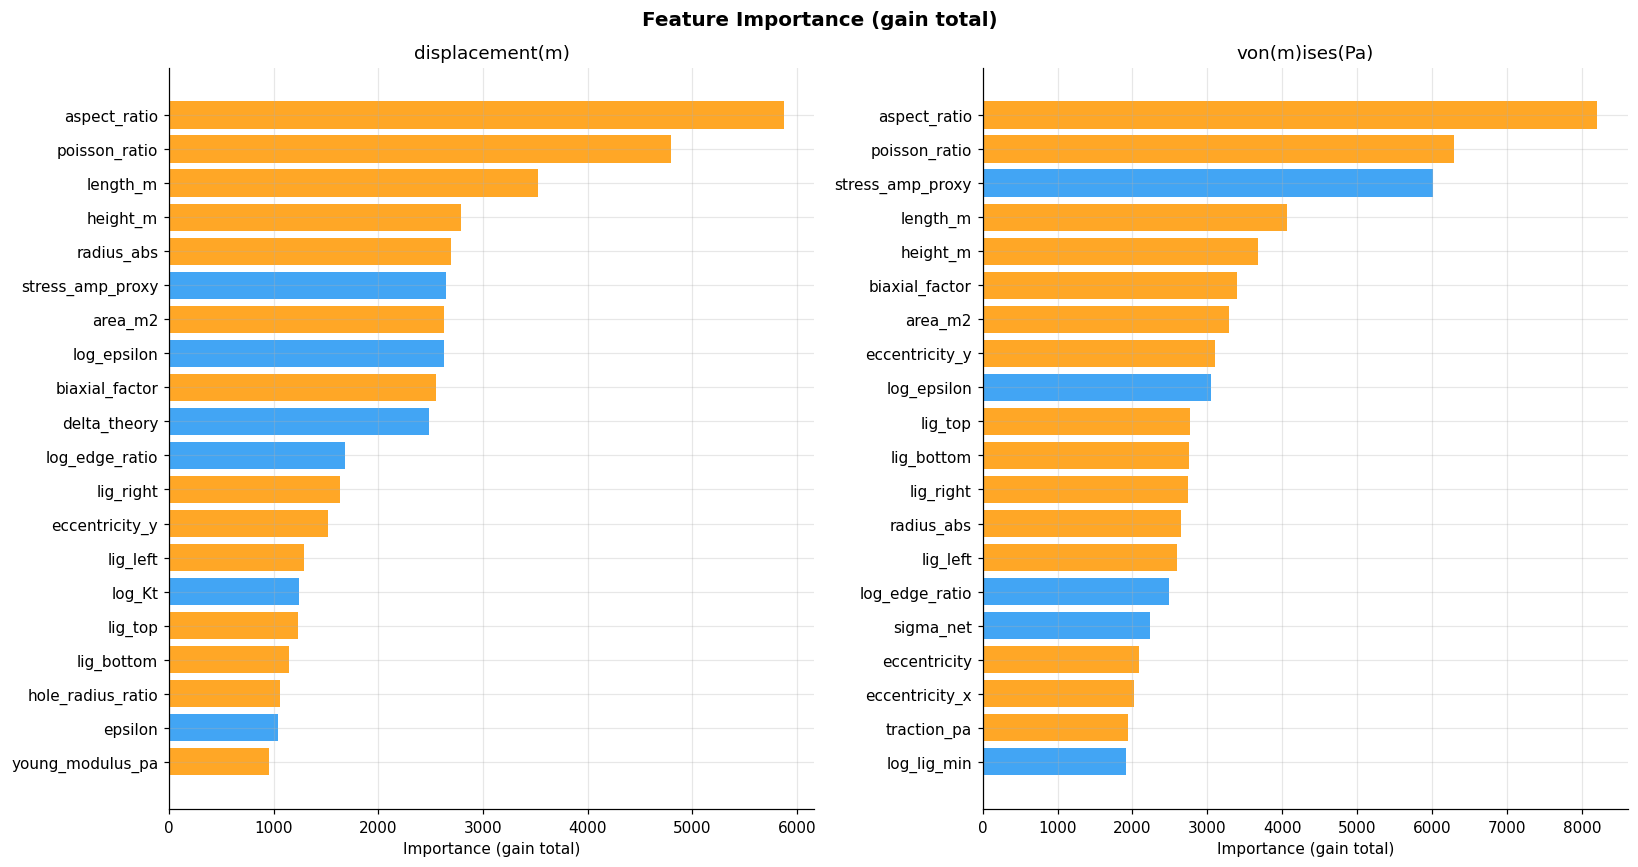

In [28]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Feature Importance (gain total)', fontsize=13, fontweight='bold')

for ax, target in zip(axes, TARGET_COLS):
    imp = pd.Series(trained_models[target].feature_importances_,
                    index=feat_cols).sort_values(ascending=True).tail(20)
    bar_colors = ['#2196F3' if any(k in f for k in
                  ['delta_theory', 'epsilon', 'sigma_net', 'Kt', 'stress_amp',
                   'log_', 'logE', 'logS'])
                  else '#FF9800' for f in imp.index]
    ax.barh(imp.index, imp.values, color=bar_colors, alpha=0.85)
    ax.set_xlabel('Importance (gain total)')
    ax.set_title(target.replace('max_', '').replace('_m', '(m)').replace('_pa', '(Pa)'))

plt.tight_layout()
plt.show()

---
## 6. Sauvegarde

In [ ]:
#
 
─
─
 
M
o
d
e
l
 
s
a
v
i
n
g
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

#
 
S
e
t
 
O
V
E
R
W
R
I
T
E
=
T
r
u
e
 
t
o
 
o
v
e
r
w
r
i
t
e
 
e
x
i
s
t
i
n
g
 
m
o
d
e
l
s
.

O
V
E
R
W
R
I
T
E
 
=
 
F
a
l
s
e


f
o
r
 
t
a
r
g
e
t
 
i
n
 
T
A
R
G
E
T
_
C
O
L
S
:

 
 
 
 
p
a
t
h
 
=
 
M
O
D
E
L
_
D
I
R
 
/
 
f
'
l
g
b
m
_
{
t
a
r
g
e
t
}
.
j
o
b
l
i
b
'

 
 
 
 
i
f
 
p
a
t
h
.
e
x
i
s
t
s
(
)
 
a
n
d
 
n
o
t
 
O
V
E
R
W
R
I
T
E
:

 
 
 
 
 
 
 
 
p
r
i
n
t
(
f
'
[
S
K
I
P
]
 
{
p
a
t
h
.
n
a
m
e
}
 
e
x
i
s
t
e
 
d
é
j
à
.
 
M
e
t
t
r
e
 
O
V
E
R
W
R
I
T
E
=
T
r
u
e
 
p
o
u
r
 
é
c
r
a
s
e
r
.
'
)

 
 
 
 
 
 
 
 
c
o
n
t
i
n
u
e

 
 
 
 
j
o
b
l
i
b
.
d
u
m
p
(
{

 
 
 
 
 
 
 
 
'
m
o
d
e
l
'
:
 
 
 
 
 
 
 
t
r
a
i
n
e
d
_
m
o
d
e
l
s
[
t
a
r
g
e
t
]
,

 
 
 
 
 
 
 
 
'
f
e
a
t
u
r
e
_
c
o
l
s
'
:
 
f
e
a
t
_
c
o
l
s
,

 
 
 
 
 
 
 
 
'
e
n
c
o
d
e
r
'
:
 
 
 
 
 
e
n
c
,

 
 
 
 
 
 
 
 
'
t
a
r
g
e
t
'
:
 
 
 
 
 
 
t
a
r
g
e
t
,

 
 
 
 
 
 
 
 
'
b
e
s
t
_
p
a
r
a
m
s
'
:
 
b
e
s
t
_
p
a
r
a
m
s
_
p
e
r
_
t
a
r
g
e
t
[
t
a
r
g
e
t
]
,

 
 
 
 
}
,
 
p
a
t
h
)

 
 
 
 
p
r
i
n
t
(
f
'
[
O
K
]
 
S
a
u
v
e
g
a
r
d
é
 
:
 
{
p
a
t
h
}
'
)


#
 
S
a
v
e
 
m
e
t
r
i
c
s

r
o
w
s
 
=
 
[
]

f
o
r
 
t
a
r
g
e
t
 
i
n
 
T
A
R
G
E
T
_
C
O
L
S
:

 
 
 
 
f
o
r
 
s
p
l
i
t
 
i
n
 
[
'
v
a
l
'
,
 
'
t
e
s
t
'
]
:

 
 
 
 
 
 
 
 
m
 
=
 
r
e
s
u
l
t
s
[
t
a
r
g
e
t
]
[
s
p
l
i
t
]

 
 
 
 
 
 
 
 
r
o
w
s
.
a
p
p
e
n
d
(
{

 
 
 
 
 
 
 
 
 
 
 
 
'
m
o
d
e
l
'
:
 
'
l
g
b
m
_
l
o
g
_
t
r
a
n
s
f
o
r
m
_
o
p
t
u
n
a
'
 
i
f
 
U
S
E
_
O
P
T
U
N
A
 
e
l
s
e
 
'
l
g
b
m
_
l
o
g
_
t
r
a
n
s
f
o
r
m
_
m
a
n
u
a
l
'
,

 
 
 
 
 
 
 
 
 
 
 
 
'
t
a
r
g
e
t
'
:
 
t
a
r
g
e
t
,
 
'
s
p
l
i
t
'
:
 
s
p
l
i
t
,

 
 
 
 
 
 
 
 
 
 
 
 
'
n
_
r
o
w
s
'
:
 
l
e
n
(
v
a
l
)
 
i
f
 
s
p
l
i
t
 
=
=
 
'
v
a
l
'
 
e
l
s
e
 
l
e
n
(
t
e
s
t
)
,

 
 
 
 
 
 
 
 
 
 
 
 
'
r
2
_
l
o
g
'
:
 
m
[
'
R
2
_
l
o
g
'
]
,
 
'
r
m
s
e
_
l
o
g
'
:
 
m
[
'
R
M
S
E
_
l
o
g
'
]
,

 
 
 
 
 
 
 
 
 
 
 
 
'
r
2
_
o
r
i
g
'
:
 
m
[
'
R
2
_
o
r
i
g
'
]
,
 
'
r
m
s
e
_
o
r
i
g
'
:
 
m
[
'
R
M
S
E
_
o
r
i
g
'
]
,

 
 
 
 
 
 
 
 
 
 
 
 
'
m
a
e
_
o
r
i
g
'
:
 
m
[
'
M
A
E
_
o
r
i
g
'
]
,
 
'
m
a
p
e
'
:
 
m
[
'
M
A
P
E
'
]
,

 
 
 
 
 
 
 
 
}
)


m
e
t
r
i
c
s
_
p
a
t
h
 
=
 
M
O
D
E
L
_
D
I
R
 
/
 
'
a
d
v
a
n
c
e
d
_
m
e
t
r
i
c
s
.
c
s
v
'

p
d
.
D
a
t
a
F
r
a
m
e
(
r
o
w
s
)
.
t
o
_
c
s
v
(
m
e
t
r
i
c
s
_
p
a
t
h
,
 
i
n
d
e
x
=
F
a
l
s
e
)

p
r
i
n
t
(
f
'
\
n
M
é
t
r
i
q
u
e
s
 
s
a
u
v
e
g
a
r
d
é
e
s
 
:
 
{
m
e
t
r
i
c
s
_
p
a
t
h
}
'
)